# Sprint 5 - PyTorch Production Candidate

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** PyTorch production-candidate training and evaluation only  
**Frozen dataset version:** `data/processed/sprint_03_preprocessed_v1/`  
**Target:** `is_claim`

This notebook trains a production-grade PyTorch binary classifier on the frozen Sprint 3 feature matrices, evaluates it against the approved Sprint 4 classical benchmarks, and stops before any API, frontend, or Sprint 6 work.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ml_pipeline import ml_engineer as eng

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

In [2]:
dataset = eng.load_benchmark_dataset()
search_results = eng.run_pytorch_hyperparameter_search(dataset)
selected_experiment = search_results['selected_experiment']
selected_history = search_results['histories'][search_results['selected_experiment_id']]
validation_evaluation = selected_experiment['validation_evaluation']
holdout_evaluation = eng.evaluate_final_pytorch_candidate(search_results, dataset)
threshold_table = eng.threshold_metrics_table(dataset.y_validation, validation_evaluation['scores'])
threshold_choice = eng.recommend_underwriting_threshold(threshold_table)
classical_results = eng.run_classical_benchmark(dataset)
comparison = eng.benchmark_comparison_with_pytorch(classical_results, holdout_evaluation)
leaderboard = eng.model_leaderboard_summary(comparison)
ranking = eng.model_ranking_table(comparison)
rf_scores = classical_results['random_forest']['holdout_evaluation']['scores']
bootstrap = eng.bootstrap_comparison_table(dataset.y_holdout, holdout_evaluation['scores'], rf_scores, n_bootstrap=500)
importance = eng.pytorch_permutation_importance(selected_experiment['model'], dataset.X_holdout, dataset.y_holdout, metric_name='roc_auc', n_repeats=2)
gradients = eng.pytorch_gradient_sensitivity(selected_experiment['model'], dataset.X_holdout)
risk_summary = eng.pytorch_risk_segment_summary(selected_experiment['model'], dataset.X_holdout, dataset.y_holdout)
domain_summary = eng.domain_feature_summary(risk_summary['feature_deltas'], top_n=12)

print('Selected experiment ID:', search_results['selected_experiment_id'])
print('Selected checkpoint:', search_results['selected_checkpoint_path'])
print('Selected config:', search_results['selected_config_path'])
print('Torch device support:', eng.training_device())

Selected experiment ID: 3
Selected checkpoint: C:\Users\97252\Desktop\ML CARS project\scaffold-main\models\sprint_05_candidate\pytorch_best_model.pt
Selected config: C:\Users\97252\Desktop\ML CARS project\scaffold-main\models\sprint_05_candidate\pytorch_best_model_config.json
Torch device support: cpu


## Phase 1 - Baseline Neural Network

In [3]:
display(eng.pytorch_training_setup_table(dataset, selected_experiment['config'], max_epochs=50, patience=8))
display(eng.architecture_summary_table(dataset, search_results))

,setting,value
0,dataset_version,C:\Users\97252\Desktop\ML CARS project\scaffol...
1,device,cpu
2,input_dim,61
3,hidden_dims,64 -> 32
4,dropout_rate,0.2
5,learning_rate,0.001
6,batch_size,512
7,weight_decay,0.0001
8,use_pos_weight,True
9,max_epochs,50


,component,details
0,Input layer,61 features
1,Hidden layer 1,64
2,Hidden layer 2,32
3,Output layer,1 logit
4,Dropout rate,0.2
5,Trainable parameters,6081


The selected baseline architecture follows the requested tabular pattern:

`Input -> Linear -> ReLU -> Dropout -> Linear -> ReLU -> Dropout -> Linear -> Output Logit`

Training uses `BCEWithLogitsLoss`, `Adam`, a fixed seed, and GPU-aware device selection. In this local environment `torch` is CPU-only, but the code will move to CUDA automatically when available.

## Phase 2 - Imbalance Handling

In [4]:
imbalance_experiments = search_results['experiments_table'].sort_values('experiment_id').reset_index(drop=True)
display(imbalance_experiments[['experiment_id', 'use_pos_weight', 'loss_function', 'best_validation_precision', 'best_validation_recall', 'best_validation_f1', 'best_validation_roc_auc', 'best_validation_pr_auc']])

,experiment_id,use_pos_weight,loss_function,best_validation_precision,best_validation_recall,best_validation_f1,best_validation_roc_auc,best_validation_pr_auc
0,1,False,BCEWithLogitsLoss,0.000000,0.000000,0.000000,0.594486,0.088698
1,2,True,BCEWithLogitsLoss + pos_weight,0.081536,0.645907,0.144795,0.613360,0.097250
2,3,True,BCEWithLogitsLoss + pos_weight,0.081577,0.688612,0.145873,0.618064,0.103645
3,4,True,BCEWithLogitsLoss + pos_weight,0.079884,0.686833,0.143122,0.609954,0.095246
4,5,True,BCEWithLogitsLoss + pos_weight,0.079924,0.674377,0.142911,0.610282,0.094970
5,6,True,BCEWithLogitsLoss + pos_weight,0.079146,0.633452,0.140711,0.608965,0.098240
6,7,True,BCEWithLogitsLoss + pos_weight,0.079879,0.658363,0.142472,0.613822,0.097294
7,8,False,BCEWithLogitsLoss,0.000000,0.000000,0.000000,0.593125,0.088124


The unweighted `BCEWithLogitsLoss` runs collapsed into majority-class behavior at the default threshold: validation recall and precision both fell to zero because the model predicted almost all rows as non-claims.

Adding `pos_weight` materially improved minority-class capture and became the required production path for this dataset.

## Phase 3 - Hyperparameter Search

In [5]:
display(search_results['experiments_table'])

,experiment_id,hidden_dims,learning_rate,batch_size,dropout_rate,weight_decay,use_pos_weight,loss_function,parameter_count,epochs_trained,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_precision,best_validation_recall,best_validation_f1,best_validation_roc_auc,best_validation_pr_auc,checkpoint_path,device_used
0,3,64 -> 32,0.0010,512,0.20,0.00010,True,BCEWithLogitsLoss + pos_weight,6081,50,48,1.266723,0.484355,0.081577,0.688612,0.145873,0.618064,0.103645,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
1,6,256 -> 64,0.0010,256,0.25,0.00001,True,BCEWithLogitsLoss + pos_weight,32385,34,26,1.284533,0.505291,0.079146,0.633452,0.140711,0.608965,0.098240,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
2,7,128 -> 64,0.0020,256,0.30,0.00010,True,BCEWithLogitsLoss + pos_weight,16257,34,26,1.289141,0.493230,0.079879,0.658363,0.142472,0.613822,0.097294,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
3,2,128 -> 64,0.0010,512,0.20,0.00010,True,BCEWithLogitsLoss + pos_weight,16257,34,26,1.278582,0.512117,0.081536,0.645907,0.144795,0.613360,0.097250,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
4,4,256 -> 128,0.0005,512,0.30,0.00010,True,BCEWithLogitsLoss + pos_weight,48897,39,31,1.273705,0.474115,0.079884,0.686833,0.143122,0.609954,0.095246,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
5,5,128 -> 32,0.0005,256,0.10,0.00010,True,BCEWithLogitsLoss + pos_weight,12097,34,26,1.277622,0.482763,0.079924,0.674377,0.142911,0.610282,0.094970,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
6,1,128 -> 64,0.0010,512,0.20,0.00010,False,BCEWithLogitsLoss,16257,40,32,0.235587,0.936056,0.000000,0.000000,0.000000,0.594486,0.088698,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu
7,8,256 -> 64,0.0005,256,0.20,0.00001,False,BCEWithLogitsLoss,32385,22,14,0.235465,0.936056,0.000000,0.000000,0.000000,0.593125,0.088124,C:\Users\97252\Desktop\ML CARS project\scaffol...,cpu


Hyperparameters tuned in this sprint:

- hidden-layer width
- learning rate
- batch size
- dropout rate
- weight decay
- loss weighting with and without `pos_weight`

Selection rule: rank experiments by validation `PR-AUC`, then `ROC-AUC`, then `Recall`, then `F1`.

## Phase 4 - Training Monitoring

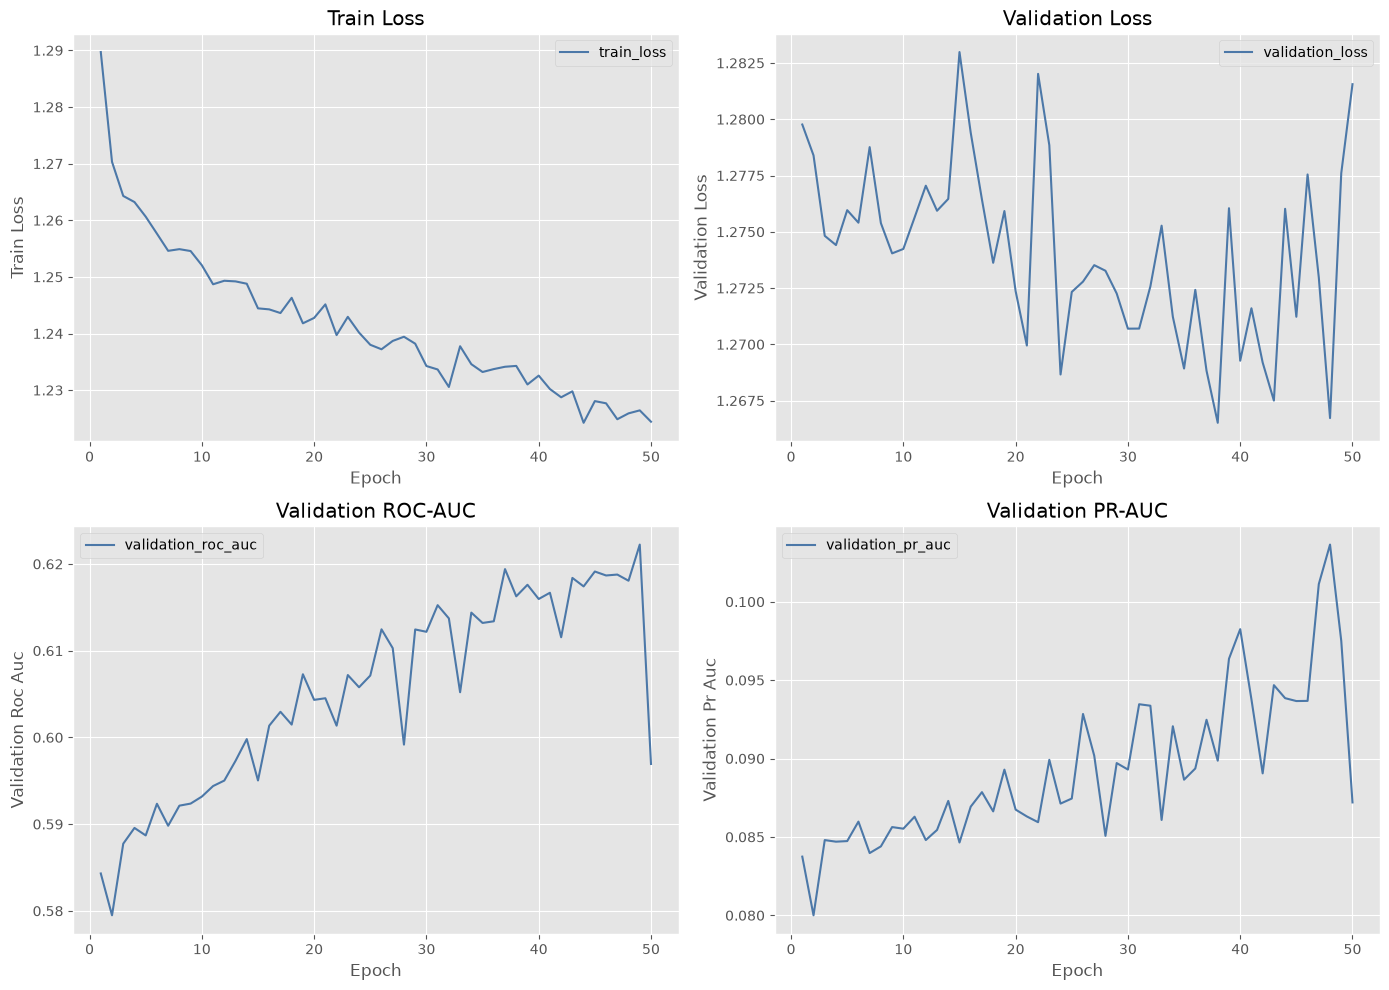

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
eng.training_history_plot(selected_history, axes[0, 0], 'train_loss', 'Train Loss')
eng.training_history_plot(selected_history, axes[0, 1], 'validation_loss', 'Validation Loss')
eng.training_history_plot(selected_history, axes[1, 0], 'validation_roc_auc', 'Validation ROC-AUC')
eng.training_history_plot(selected_history, axes[1, 1], 'validation_pr_auc', 'Validation PR-AUC')
plt.tight_layout()

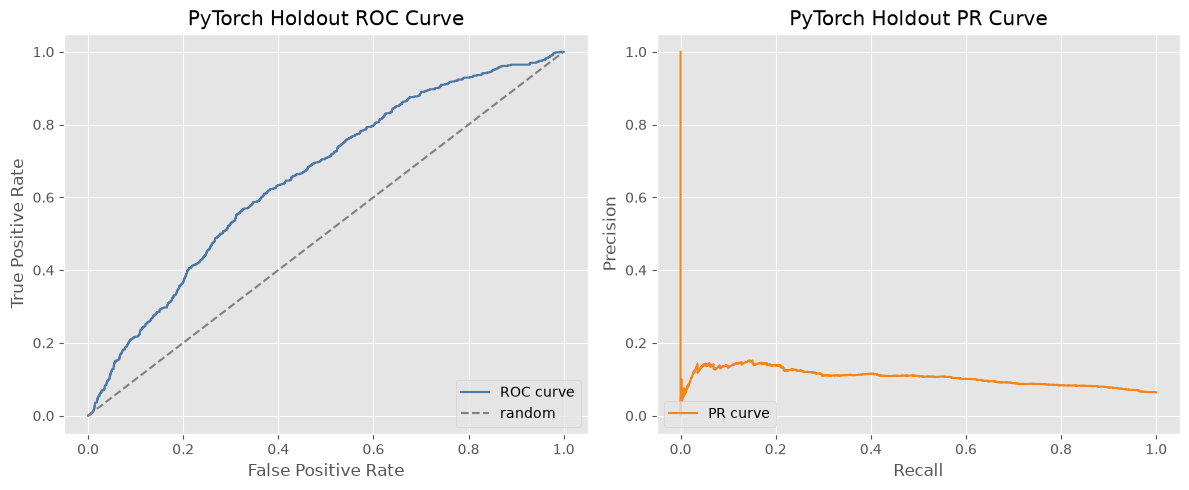

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
eng.plot_roc_curve(holdout_evaluation['roc_curve'], axes[0], 'PyTorch Holdout ROC Curve')
eng.plot_precision_recall_curve(holdout_evaluation['precision_recall_curve'], axes[1], 'PyTorch Holdout PR Curve')
plt.tight_layout()

Early stopping and checkpointing are driven by validation quality, with best checkpoints selected by `PR-AUC` first and then `ROC-AUC`, `Recall`, `F1`, and validation loss. The selected experiment trained for `50` epochs and stored its best checkpoint at epoch `48`.

## Phase 5 - Holdout Evaluation

In [8]:
holdout_metrics = pd.DataFrame([holdout_evaluation['metrics']])
display(holdout_metrics)
display(holdout_evaluation['confusion_matrix'])

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.492945,0.086975,0.729537,0.155421,0.655324,0.10462


,pred_0,pred_1
actual_0,3922,4304
actual_1,152,410


## Phase 6 - Threshold Analysis

In [9]:
display(threshold_table)
display(pd.DataFrame([threshold_choice]))

,threshold,precision,recall,f1
0,0.20,0.064397,0.992883,0.120949
1,0.25,0.064555,0.964413,0.121009
2,0.30,0.067529,0.937722,0.125986
3,0.35,0.071010,0.905694,0.131695
4,0.40,0.073354,0.852313,0.135082
5,0.50,0.081577,0.688612,0.145873


,threshold,precision,recall,f1
0,0.5,0.081577,0.688612,0.145873


Threshold `0.50` remains the recommended underwriting threshold from the tested grid because it gives the highest validation `F1`. Lower thresholds push recall even higher, but precision falls quickly and would create a much heavier manual-review burden.

## Phase 7 - Model Explainability

In [10]:
display(importance.head(20))
display(gradients.head(20))
display(risk_summary['risk_band_summary'])
display(domain_summary)

,feature,baseline_metric,mean_metric_drop,std_metric_drop,metric_name
0,policy_tenure,0.655324,0.098112,0.001609,roc_auc
1,age_of_car,0.655324,0.068076,0.004020,roc_auc
2,torque_nm,0.655324,0.009339,0.001095,roc_auc
3,length,0.655324,0.008782,0.001361,roc_auc
4,ncap_rating,0.655324,0.008152,0.001285,roc_auc
5,power_to_weight,0.655324,0.007430,0.002069,roc_auc
6,steering_type__Power,0.655324,0.007211,0.001163,roc_auc
7,width,0.655324,0.006447,0.000253,roc_auc
8,rear_brakes_type__Drum,0.655324,0.006193,0.001365,roc_auc
9,parking_assist_score,0.655324,0.006028,0.000558,roc_auc


,feature,average_abs_gradient
0,age_of_car,0.163598
1,policy_tenure,0.101400
2,is_speed_alert,0.030944
3,steering_type__Power,0.022607
4,rear_brakes_type__Drum,0.022064
5,segment__B1,0.021399
6,age_of_policyholder,0.021076
7,is_front_fog_lights,0.019052
8,is_parking_sensors,0.018848
9,population_density,0.017805


,risk_band,rows,average_predicted_probability,actual_claim_rate
0,top_decile,879,0.685784,0.135381
1,bottom_decile,879,0.245562,0.022753


,feature,high_risk_mean,low_risk_mean,difference,abs_difference,domain
0,policy_tenure,-0.022234,-1.242858,1.220624,1.220624,policy
1,age_of_car,-0.986430,0.171069,-1.157500,1.157500,vehicle_profile
2,height,-0.664964,0.130608,-0.795572,0.795572,vehicle_profile
3,vehicle_volume_proxy,-0.793376,-0.040511,-0.752865,0.752865,vehicle_profile
4,power_bhp,-0.775621,-0.078653,-0.696968,0.696968,vehicle_profile
5,length,-0.738649,-0.071509,-0.667140,0.667140,vehicle_profile
6,displacement,-0.698435,-0.045683,-0.652752,0.652752,vehicle_profile
7,width,-0.710577,-0.082893,-0.627684,0.627684,vehicle_profile
8,turning_radius,-0.689984,-0.072250,-0.617734,0.617734,vehicle_profile
9,gross_weight,-0.658968,-0.046653,-0.612316,0.612316,vehicle_profile


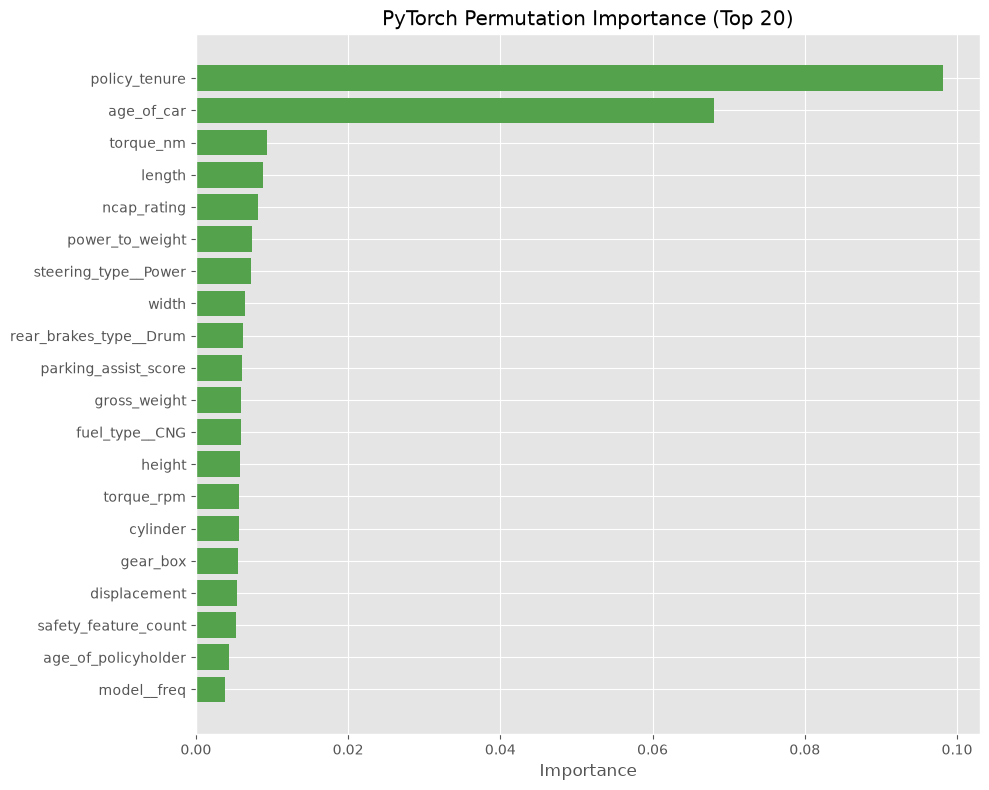

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
eng.plot_feature_importance(importance.head(20).rename(columns={'mean_metric_drop': 'importance'}), ax, 'PyTorch Permutation Importance (Top 20)')
plt.tight_layout()

The top-risk holdout decile reaches an actual claim rate of about `13.5%`, compared with about `2.3%` in the bottom decile. The main risk signals remain concentrated around policy tenure, car age, customer age, safety proxies, and smaller or lighter vehicle profiles.

## Phase 8 - Benchmark Comparison

In [12]:
display(comparison)
display(ranking)
display(leaderboard)
display(bootstrap)

,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656
1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
3,XGBoost,Skipped: xgboost is not installed in the local...,NaN,NaN,NaN,NaN,NaN,NaN
4,PyTorch Neural Net,Evaluated,0.492945,0.086975,0.729537,0.155421,0.655324,0.104620


,rank,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
1,2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
2,3,PyTorch Neural Net,Evaluated,0.492945,0.086975,0.729537,0.155421,0.655324,0.104620
3,4,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656


,category,model
0,Best ROC-AUC,Random Forest
1,Best Recall,PyTorch Neural Net
2,Best Precision,Random Forest
3,Best PR-AUC,Decision Tree
4,Most Explainable Model,Logistic Regression


,metric_name,observed_difference,bootstrap_mean_difference,ci_lower,ci_upper,n_bootstrap,statistically_meaningful
0,roc_auc,-0.007124,-0.007066,-0.017460,0.004833,500,False
1,pr_auc,-0.005893,-0.005937,-0.013876,0.000317,500,False


The PyTorch candidate wins holdout recall, but it does not beat the Random Forest on holdout `ROC-AUC` or `PR-AUC`. The bootstrap comparison against the Random Forest shows confidence intervals that cross zero for both metrics, so there is no statistically meaningful improvement in ranking quality.

## Phase 9 - Sprint Recommendation

In [13]:
recommendation_table = pd.DataFrame([
    {
        'question': 'Did PyTorch outperform Random Forest?',
        'answer': 'No',
        'detail': 'PyTorch improved recall but trailed Random Forest on holdout ROC-AUC and PR-AUC.'
    },
    {
        'question': 'How large was the difference?',
        'answer': 'ROC-AUC -0.0071, PR-AUC -0.0059, Recall +0.0854',
        'detail': 'Differences are measured as PyTorch minus Random Forest on the holdout split.'
    },
    {
        'question': 'Was the improvement statistically meaningful?',
        'answer': 'No',
        'detail': 'Bootstrap confidence intervals for ROC-AUC and PR-AUC differences both cross zero.'
    },
    {
        'question': 'Should PyTorch become the production model?',
        'answer': 'No',
        'detail': 'Random Forest remains the stronger production baseline. PyTorch stays as the course-quality production candidate study, not the deployment recommendation.'
    },
])
display(recommendation_table)

,question,answer,detail
0,Did PyTorch outperform Random Forest?,No,PyTorch improved recall but trailed Random For...
1,How large was the difference?,"ROC-AUC -0.0071, PR-AUC -0.0059, Recall +0.0854",Differences are measured as PyTorch minus Rand...
2,Was the improvement statistically meaningful?,No,Bootstrap confidence intervals for ROC-AUC and...
3,Should PyTorch become the production model?,No,Random Forest remains the stronger production ...


Sprint 5 stops here. No APIs were built, no frontend work was started, and Sprint 6 was not started.